# Autoencoder Retraining Stability (LAD-Grouped CV)

**Experiment Design (leave whole Local Authority Districts out):**
1. Map every OA to its 2022 Local Authority District (`LAD22CD`)
2. Bin whole LADs into `n_folds` folds by greedy balanced bin-packing so each fold holds ~20% of OAs (**no LAD is ever split** across folds)
3. For each fold: train AE on the other `n_folds - 1` folds, evaluate on the held-out fold


This is a **leave-whole-LADs-out** generalization test: an entire administrative area is held
out at once, so the AE cannot exploit within-LAD similarity between train and test OAs. Folds are
balanced to ~20% of OAs each but are **not** spatially contiguous (each fold's LADs are scattered
nationwide). 

## 1. Setup and Imports

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import yaml
from torchgeodemo import autoencoder_train_latent
from scipy.spatial import procrustes
from scipy.stats import pearsonr
import geopandas as gpd
import os
import pickle
from tqdm import tqdm
from itertools import combinations
import json
import warnings
warnings.filterwarnings('ignore')

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu128
CUDA available: True


## 2. Configuration

In [2]:
# Helper function for layer size generation
def gen_layer_sizes(input_size, latent_size, num_layers, scaling_type="lin"):
    """Generate encoder/decoder layer widths."""
    if scaling_type == "mul":
        scale = (latent_size / input_size) ** (1 / (num_layers - 1))
        return [int(input_size * scale ** i) for i in range(1, num_layers)]
    if scaling_type == "lin":
        step = (latent_size - input_size) / (num_layers - 1)
        return [int(input_size + step * i) for i in range(1, num_layers)]
    raise ValueError("Invalid scaling type. Use 'mul' or 'lin'.")

# Training parameters
n_epochs = 500
batch_size = 0.01
scaling_type = "lin"

# LAD-grouped CV configuration (leave whole LADs out; each fold ~20% of OAs)
n_folds   = 5     # folds per repeat -> each fold ~20% of OAs (groups of whole LADs)
n_repeats = 1      # LAD shuffles; repeat 0 (a single shuffle) is used for the paper
base_split_seed = 42

# Paths
data_path       = "../data/census_data/engcensus_cleaned_scaled.parquet"
geofile_path    = "../data/geofiles/Output_Areas_(December_2021)_Boundaries_EW_BFE_(V9)_and_RUC.geojson"
lad_lookup_path = "../data/geofiles/Output_Area_to_Lower_layer_Super_Output_Area_to_Middle_layer_Super_Output_Area_to_Local_Authority_District_(December_2021)_Lookup_in_England_and_Wales_v3.csv"
output_dir      = f"../AE_outputs/retraining_stability_{n_epochs}epochs_{scaling_type}scaling_lad_blocked"
os.makedirs(output_dir, exist_ok=True)
os.makedirs(f"{output_dir}/data/", exist_ok=True)
os.makedirs(f"{output_dir}/models/", exist_ok=True)
os.makedirs(f"{output_dir}/yamls/", exist_ok=True)

bottleneck_sizes = [128, 100, 64, 32, 16, 8, 4, 2]
base_seed = 20210321

print("Configuration:")
print(f"  Bottleneck sizes:   {bottleneck_sizes}")
print(f"  LAD-grouped folds:  {n_folds} (each ~{100/n_folds:.0f}% of OAs, whole LADs)")
print(f"  Repeats:            {n_repeats}")
print(f"  Total fits per dim: {n_folds * n_repeats}")
print(f"  Total models:       {len(bottleneck_sizes) * n_folds * n_repeats}")
print(f"  Training epochs:    {n_epochs}")
print(f"  Output directory:   {output_dir}")

Configuration:
  Bottleneck sizes:   [128, 100, 64, 32, 16, 8, 4, 2]
  LAD-grouped folds:  5 (each ~20% of OAs, whole LADs)
  Repeats:            10
  Total fits per dim: 50
  Total models:       400
  Training epochs:    500
  Output directory:   ../AE_outputs/retraining_stability_500epochs_linscaling_lad_blocked


## 3. Utility Functions

In [3]:
def procrustes_align(X_source, X_target):
    """
    Align X_source to X_target using Procrustes transformation.
    Returns: aligned X_source, disparity
    """
    mtx1, mtx2, disparity = procrustes(X_target, X_source)
    return mtx1, disparity

def compute_pairwise_correlations(embeddings_list):
    """
    Compute pairwise correlations between all embedding pairs.
    
    Parameters:
    - embeddings_list: list of embedding arrays (each shape: n_samples x n_dims)
    
    Returns:
    - mean_correlation: mean across all pairs
    - correlation_matrix: n_runs x n_runs matrix of correlations
    - all_correlations: flat array of all pairwise correlations
    """
    n_runs = len(embeddings_list)
    correlation_matrix = np.ones((n_runs, n_runs))
    all_correlations = []
    
    for i, j in combinations(range(n_runs), 2):
        # Align j to i using Procrustes
        aligned_j, _ = procrustes_align(embeddings_list[j], embeddings_list[i])
        
        # Compute per-dimension correlations
        dim_corrs = []
        for dim in range(embeddings_list[i].shape[1]):
            corr, _ = pearsonr(embeddings_list[i][:, dim], aligned_j[:, dim])
            dim_corrs.append(corr)
        
        mean_corr = np.mean(dim_corrs)
        correlation_matrix[i, j] = mean_corr
        correlation_matrix[j, i] = mean_corr
        all_correlations.append(mean_corr)
    
    return np.mean(all_correlations), correlation_matrix, np.array(all_correlations)

def compute_per_oa_std(embeddings_list):
    """
    Compute per-OA standard deviation across runs.
    First aligns all embeddings to the first run using Procrustes.
    
    Returns: array of shape (n_samples,) with std for each OA
    """
    n_runs = len(embeddings_list)
    reference = embeddings_list[0]
    
    # Align all to reference
    aligned_embeddings = [reference]
    for i in range(1, n_runs):
        aligned, _ = procrustes_align(embeddings_list[i], reference)
        aligned_embeddings.append(aligned)
    
    # Stack and compute std across runs
    stacked = np.stack(aligned_embeddings, axis=0)  # shape: (n_runs, n_samples, n_dims)
    per_oa_std = np.mean(stacked.std(axis=0), axis=1)  # mean std across dimensions
    
    return per_oa_std

print("Utility functions defined")

Utility functions defined


## 4. Helper Functions for AE Training via YAML

In [4]:
def train_ae_via_yaml(data_df, run_name, latent_dim, working_dir, seed,
                      n_epochs=250, batch_size=0.01, scaling_type="lin"):
    """
    Train autoencoder using torchgeodemo with YAML configuration.
    Skips training if output files already exist.
    
    Parameters:
    - data_df: DataFrame with data (must have 'OA' column)
    - run_name: name for this run (e.g., 'run_0', 'run_1')
    - latent_dim: bottleneck dimension
    - working_dir: directory for outputs
    - seed: random seed for this run
    - n_epochs: training epochs
    - batch_size: batch size fraction
    - scaling_type: 'lin' or 'mul' for layer scaling
    
    Returns: embeddings (numpy array)
    """
    # torchgeodemo saves files with double underscores directly in working_dir
    # Include n_epochs in filename to distinguish different training runs
    model_nickname = f"stability_{run_name}__ae_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
    latent_csv_path = f"{working_dir}/{model_nickname}__latent.csv"
    
    # Check if already trained - skip if latent CSV exists
    if os.path.exists(latent_csv_path):
        print(f"[{run_name}] Found existing output ({n_epochs} epochs), skipping training")
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
        print(f"[{run_name}] Loaded embeddings: {embeddings.shape}")
        return embeddings
    
    print(f"[{run_name}] Training (seed={seed}, epochs={n_epochs})")
    torch.manual_seed(seed)
    
    if 'OA' not in data_df.columns:
        data_df = data_df.reset_index()
    
    input_dim = data_df.shape[1] - 1
    encoder_sizes = gen_layer_sizes(input_dim, latent_dim, num_layers=4, scaling_type=scaling_type)
    
    yaml_config = {
        "data": {
            "source": "TEMP",
            "nickname": f"stability_{run_name}",
            "id_col": "OA"
        },
        "working_dir": working_dir,
        "autoencoder": {
            "nickname": f"ae_{latent_dim}d_{run_name}_{n_epochs}ep",
            "version": "1",
            "save_latent": "csv",
            "max_epochs": n_epochs,
            "batch_size": batch_size,
            "use_covariance_loss": False,
            "random_seed": seed,
            "encoder": {
                "sizes": encoder_sizes,
                "activation": "LeakyReLU"
            },
            "decoder": {
                "sizes": encoder_sizes[::-1],
                "activation": "LeakyReLU"
            }
        }
    }
    
    temp_data_path = f"{working_dir}/temp_data_{run_name}.parquet"
    data_df.to_parquet(temp_data_path)
    yaml_config["data"]["source"] = temp_data_path
    
    yaml_dir = f"{working_dir}/yamls"
    os.makedirs(yaml_dir, exist_ok=True)
    config_path = f"{yaml_dir}/config_{run_name}_{latent_dim}d_{n_epochs}ep.yaml"
    with open(config_path, 'w') as f:
        yaml.dump(yaml_config, f, default_flow_style=False)
    
    autoencoder_train_latent.main(config_path, create_latent=True, save_reco_error=False, verbose=True)
    print(f"[{run_name}] Training complete")
    
    if os.path.exists(latent_csv_path):
        latent_df = pd.read_csv(latent_csv_path, index_col="OA")
        embeddings = latent_df.values
    else:
        model_path = f"{working_dir}/{model_nickname}__model.pth"
        print(f"[{run_name}] Latent CSV missing, encoding manually")
        embeddings = load_ae_and_encode(model_path, data_df.drop(columns=['OA']))
    
    print(f"[{run_name}] Embeddings shape: {embeddings.shape}")
    return embeddings

def load_ae_and_encode(model_path, X_data):
    """Load trained AE model and encode data"""
    from torchgeodemo.models import AutoEncoder
    
    device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
    model = torch.load(model_path, map_location=device, weights_only=False)
    model.eval()
    
    if isinstance(X_data, pd.DataFrame):
        X_np = X_data.values
    else:
        X_np = X_data
    
    with torch.no_grad():
        X_tensor = torch.FloatTensor(X_np).to(device)
        embeddings = model.encode(X_tensor).cpu().numpy()
    
    return embeddings

print("YAML-based training and loading functions defined")

YAML-based training and loading functions defined


## 5. Load Data and Build Spatial Folds

In [5]:
# Load census data
df = pd.read_parquet(data_path)
if 'OA' not in df.columns:
    df = df.reset_index()
print(f"Census data: {df.shape}")

# Load OA centroids from the geofile (used only for the fold-map visualization)
print("Loading OA geometries for the fold map...")
gdf = gpd.read_file(geofile_path)
oa_col = next(c for c in gdf.columns if c.upper() in ("OA21CD", "OA11CD", "OA", "OACODE"))
centroids = gdf.geometry.centroid
gdf_c = gpd.GeoDataFrame({
    "OA": gdf[oa_col].values,
    "x": centroids.x.values,
    "y": centroids.y.values,
}, geometry=centroids, crs=gdf.crs)
print(f"  Loaded {len(gdf_c)} OA centroids in CRS {gdf.crs}")

# Merge centroids onto the data df in the order of df['OA']
coords = (
    df[['OA']]
    .merge(gdf_c[['OA', 'x', 'y']], on='OA', how='left')
)
missing = coords[['x', 'y']].isna().any(axis=1).sum()
if missing:
    print(f"  WARNING: {missing} OAs have no centroid match - dropping them")
    keep = coords[['x', 'y']].notna().all(axis=1).values
    df = df.loc[keep].reset_index(drop=True)
    coords = coords.loc[keep].reset_index(drop=True)
XY = coords[['x', 'y']].values
print(f"  Centroid array: {XY.shape}")

# --- Map each OA to its Local Authority District (LAD22CD) ---
print("Loading OA -> LAD lookup...")
lad_lookup = pd.read_csv(lad_lookup_path, usecols=['OA21CD', 'LAD22CD'], low_memory=False)
lad_lookup = lad_lookup.rename(columns={'OA21CD': 'OA', 'LAD22CD': 'LAD'})
lad_merge = df[['OA']].merge(lad_lookup, on='OA', how='left')
n_missing_lad = int(lad_merge['LAD'].isna().sum())
if n_missing_lad:
    raise ValueError(f"{n_missing_lad} OAs have no LAD match - check the lookup file")
oa_lad = lad_merge['LAD'].values                 # LAD code per OA, aligned to df
lad_oa_counts = pd.Series(oa_lad).value_counts()  # OAs per LAD
print(f"  {len(lad_oa_counts)} LADs | OA/LAD: min {lad_oa_counts.min()}, "
      f"median {int(lad_oa_counts.median())}, max {lad_oa_counts.max()}")

# --- Build folds by greedy balanced bin-packing of WHOLE LADs ---
# For each repeat: shuffle LADs (seeded), then assign each LAD to the fold that
# currently holds the fewest OAs. Whole LADs are never split, and each fold ends
# up with ~1/n_folds of all OAs.
def build_lad_folds(oa_lad, lad_oa_counts, n_folds, seed):
    rng = np.random.default_rng(seed)
    lads = lad_oa_counts.index.to_numpy()
    lads = lads[rng.permutation(len(lads))]        # random tie-break order per repeat
    fold_load = np.zeros(n_folds, dtype=np.int64)  # OAs assigned per fold so far
    lad_to_fold = {}
    for lad in lads:
        f = int(np.argmin(fold_load))              # emptiest fold
        lad_to_fold[lad] = f
        fold_load[f] += int(lad_oa_counts[lad])
    labels = np.array([lad_to_fold[l] for l in oa_lad], dtype=int)
    return labels

fold_assignments = []
for r in range(n_repeats):
    labels = build_lad_folds(oa_lad, lad_oa_counts, n_folds, base_split_seed + r)
    fold_assignments.append(labels)
    counts = np.bincount(labels, minlength=n_folds)
    lf = pd.DataFrame({'LAD': oa_lad, 'fold': labels}).drop_duplicates('LAD')
    n_lads = lf.groupby('fold')['LAD'].nunique().reindex(range(n_folds), fill_value=0).tolist()
    # sanity: no LAD may straddle two folds
    assert lf['LAD'].duplicated().sum() == 0, "a LAD was split across folds!"
    print(f"  Repeat {r}: fold OA sizes = {counts.tolist()}  "
          f"({(counts/len(labels)*100).round(1).tolist()}%)  | LADs/fold = {n_lads}")

# Persist
with open(f"{output_dir}/data/spatial_folds.pkl", 'wb') as f:
    pickle.dump({
        'grouping':        'LAD22CD',
        'method':          'greedy_balanced_binpack',
        'n_folds':         n_folds,
        'n_repeats':       n_repeats,
        'base_split_seed': base_split_seed,
        'fold_assignments': fold_assignments,
        'oa_ids':          df['OA'].values,
        'oa_lad':          oa_lad,
        'coords':          XY,
    }, f)

X_full = df.drop(columns=['OA']).values
print(f"\nData ready: X_full shape = {X_full.shape}")

Census data: (188880, 409)
Loading OA geometries for the fold map...


  Loaded 188880 OA centroids in CRS EPSG:4326
  Centroid array: (188880, 2)
Loading OA -> LAD lookup...


  331 LADs | OA/LAD: min 9, median 455, max 3325
  Repeat 0: fold OA sizes = [37820, 37313, 37770, 38014, 37963]  ([20.0, 19.8, 20.0, 20.1, 20.1]%)  | LADs/fold = [61, 68, 63, 76, 63]


  Repeat 1: fold OA sizes = [37520, 38345, 37375, 37512, 38128]  ([19.9, 20.3, 19.8, 19.9, 20.2]%)  | LADs/fold = [66, 71, 58, 70, 66]
  Repeat 2: fold OA sizes = [37503, 37600, 38719, 37354, 37704]  ([19.9, 19.9, 20.5, 19.8, 20.0]%)  | LADs/fold = [69, 63, 67, 68, 64]
  Repeat 3: fold OA sizes = [37730, 37523, 38019, 38173, 37435]  ([20.0, 19.9, 20.1, 20.2, 19.8]%)  | LADs/fold = [76, 58, 68, 68, 61]


  Repeat 4: fold OA sizes = [37952, 37812, 37503, 38028, 37585]  ([20.1, 20.0, 19.9, 20.1, 19.9]%)  | LADs/fold = [64, 63, 73, 64, 67]
  Repeat 5: fold OA sizes = [37653, 37791, 37636, 38045, 37755]  ([19.9, 20.0, 19.9, 20.1, 20.0]%)  | LADs/fold = [61, 70, 61, 72, 67]
  Repeat 6: fold OA sizes = [37591, 38046, 37819, 37692, 37732]  ([19.9, 20.1, 20.0, 20.0, 20.0]%)  | LADs/fold = [76, 66, 58, 65, 66]


  Repeat 7: fold OA sizes = [37960, 37977, 37229, 38332, 37382]  ([20.1, 20.1, 19.7, 20.3, 19.8]%)  | LADs/fold = [58, 70, 68, 63, 72]
  Repeat 8: fold OA sizes = [37583, 37697, 38051, 37959, 37590]  ([19.9, 20.0, 20.1, 20.1, 19.9]%)  | LADs/fold = [73, 73, 57, 59, 69]
  Repeat 9: fold OA sizes = [37636, 37666, 38421, 37580, 37577]  ([19.9, 19.9, 20.3, 19.9, 19.9]%)  | LADs/fold = [70, 55, 71, 68, 67]



Data ready: X_full shape = (188880, 408)


# =============================================================================
# PART 1: AUTOENCODER RETRAINING STABILITY
# =============================================================================

In [6]:
# Checkpoint per (bottleneck_size, repeat) so partial progress survives interrupts.

def get_checkpoint_path(bottleneck_size, repeat_idx):
    return f"{output_dir}/data/spcv_checkpoint_{bottleneck_size}d_rep{repeat_idx}.pkl"

def load_checkpoint(bottleneck_size, repeat_idx):
    p = get_checkpoint_path(bottleneck_size, repeat_idx)
    if os.path.exists(p):
        with open(p, 'rb') as f:
            return pickle.load(f)
    return None

def save_checkpoint(bottleneck_size, repeat_idx, payload):
    p = get_checkpoint_path(bottleneck_size, repeat_idx)
    with open(p, 'wb') as f:
        pickle.dump(payload, f)
    print(f"  Saved checkpoint: {p}")

print("Checkpoint functions defined")

Checkpoint functions defined


In [7]:
print("=" * 80)
print(f"Spatial CV training: {len(bottleneck_sizes)} dims × {n_repeats} repeats × {n_folds} folds")
print("=" * 80)

# Results stored as: results[(dim, repeat, fold)] = {
#     'test_idx', 'test_rmse', 'train_rmse', 'test_reco_error', 'train_reco_error'
# }
spcv_results = {}

for latent_dim in bottleneck_sizes:
    print(f"\n{'='*80}\nBOTTLENECK SIZE: {latent_dim}D\n{'='*80}")

    for repeat_idx in range(n_repeats):
        ckpt = load_checkpoint(latent_dim, repeat_idx)
        if ckpt is not None and ckpt.get('n_folds_done', 0) >= n_folds:
            print(f"  [skip] {latent_dim}D repeat {repeat_idx} fully cached")
            for fold_idx in range(n_folds):
                spcv_results[(latent_dim, repeat_idx, fold_idx)] = ckpt['folds'][fold_idx]
            continue

        repeat_folds = ckpt['folds'] if ckpt else {}
        labels = fold_assignments[repeat_idx]

        for fold_idx in range(n_folds):
            if fold_idx in repeat_folds:
                spcv_results[(latent_dim, repeat_idx, fold_idx)] = repeat_folds[fold_idx]
                continue

            test_mask  = labels == fold_idx
            train_mask = ~test_mask
            test_idx   = np.where(test_mask)[0]
            train_idx_ = np.where(train_mask)[0]

            df_train_fold = df.iloc[train_idx_].reset_index(drop=True)
            X_train_fold  = X_full[train_idx_]
            X_test_fold   = X_full[test_idx]

            run_name = f"{latent_dim}d_r{repeat_idx}_f{fold_idx}"
            seed = base_seed + repeat_idx * 10_000 + fold_idx * 1000
            print(f"\n  {run_name}: train={len(train_idx_)}  test={len(test_idx)}  seed={seed}")

            _ = train_ae_via_yaml(
                data_df=df_train_fold,
                run_name=run_name,
                latent_dim=latent_dim,
                working_dir=f"{output_dir}/models",
                seed=seed,
                n_epochs=n_epochs,
                batch_size=batch_size,
                scaling_type=scaling_type,
            )

            model_nickname = f"stability_{run_name}__ae_{latent_dim}d_{run_name}_{n_epochs}ep_v1"
            model_path = f"{output_dir}/models/{model_nickname}__model.pth"
            device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
            model = torch.load(model_path, map_location=device, weights_only=False)
            model.eval()

            with torch.no_grad():
                Xt = torch.FloatTensor(X_test_fold).to(device)
                Xtr = torch.FloatTensor(X_train_fold).to(device)
                test_reco  = model.decoder(model.encode(Xt)).cpu().numpy()
                train_reco = model.decoder(model.encode(Xtr)).cpu().numpy()
                test_err   = np.mean((X_test_fold  - test_reco)  ** 2, axis=1)
                train_err  = np.mean((X_train_fold - train_reco) ** 2, axis=1)

            payload = {
                'test_idx':         test_idx,
                'train_idx':        train_idx_,
                'test_reco_error':  test_err,
                'train_reco_error': train_err,
                'test_rmse':        float(np.sqrt(test_err.mean())),
                'train_rmse':       float(np.sqrt(train_err.mean())),
            }
            print(f"    train RMSE = {payload['train_rmse']*100:.4f}%   test RMSE = {payload['test_rmse']*100:.4f}%")

            spcv_results[(latent_dim, repeat_idx, fold_idx)] = payload
            repeat_folds[fold_idx] = payload
            save_checkpoint(latent_dim, repeat_idx, {
                'bottleneck_size': latent_dim,
                'repeat_idx':      repeat_idx,
                'folds':           repeat_folds,
                'n_folds_done':    len(repeat_folds),
            })

print(f"\n{'='*80}\nCOMPLETED spatial CV: {len(spcv_results)} (dim, repeat, fold) trainings\n{'='*80}")

Spatial CV training: 8 dims × 10 repeats × 5 folds

BOTTLENECK SIZE: 128D
  [skip] 128D repeat 0 fully cached
  [skip] 128D repeat 1 fully cached
  [skip] 128D repeat 2 fully cached
  [skip] 128D repeat 3 fully cached
  [skip] 128D repeat 4 fully cached
  [skip] 128D repeat 5 fully cached
  [skip] 128D repeat 6 fully cached
  [skip] 128D repeat 7 fully cached
  [skip] 128D repeat 8 fully cached
  [skip] 128D repeat 9 fully cached

BOTTLENECK SIZE: 100D
  [skip] 100D repeat 0 fully cached
  [skip] 100D repeat 1 fully cached
  [skip] 100D repeat 2 fully cached
  [skip] 100D repeat 3 fully cached
  [skip] 100D repeat 4 fully cached
  [skip] 100D repeat 5 fully cached
  [skip] 100D repeat 6 fully cached
  [skip] 100D repeat 7 fully cached
  [skip] 100D repeat 8 fully cached
  [skip] 100D repeat 9 fully cached

BOTTLENECK SIZE: 64D
  [skip] 64D repeat 0 fully cached
  [skip] 64D repeat 1 fully cached
  [skip] 64D repeat 2 fully cached
  [skip] 64D repeat 3 fully cached
  [skip] 64D repeat 4

  [skip] 64D repeat 8 fully cached


  [skip] 64D repeat 9 fully cached

BOTTLENECK SIZE: 32D


  [skip] 32D repeat 0 fully cached
  [skip] 32D repeat 1 fully cached
  [skip] 32D repeat 2 fully cached
  [skip] 32D repeat 3 fully cached
  [skip] 32D repeat 4 fully cached
  [skip] 32D repeat 5 fully cached
  [skip] 32D repeat 6 fully cached
  [skip] 32D repeat 7 fully cached
  [skip] 32D repeat 8 fully cached
  [skip] 32D repeat 9 fully cached

BOTTLENECK SIZE: 16D
  [skip] 16D repeat 0 fully cached
  [skip] 16D repeat 1 fully cached
  [skip] 16D repeat 2 fully cached
  [skip] 16D repeat 3 fully cached
  [skip] 16D repeat 4 fully cached
  [skip] 16D repeat 5 fully cached
  [skip] 16D repeat 6 fully cached
  [skip] 16D repeat 7 fully cached
  [skip] 16D repeat 8 fully cached
  [skip] 16D repeat 9 fully cached

BOTTLENECK SIZE: 8D
  [skip] 8D repeat 0 fully cached
  [skip] 8D repeat 1 fully cached


  [skip] 8D repeat 2 fully cached
  [skip] 8D repeat 3 fully cached


  [skip] 8D repeat 4 fully cached


  [skip] 8D repeat 5 fully cached
  [skip] 8D repeat 6 fully cached
  [skip] 8D repeat 7 fully cached
  [skip] 8D repeat 8 fully cached
  [skip] 8D repeat 9 fully cached

BOTTLENECK SIZE: 4D
  [skip] 4D repeat 0 fully cached
  [skip] 4D repeat 1 fully cached
  [skip] 4D repeat 2 fully cached
  [skip] 4D repeat 3 fully cached
  [skip] 4D repeat 4 fully cached
  [skip] 4D repeat 5 fully cached
  [skip] 4D repeat 6 fully cached
  [skip] 4D repeat 7 fully cached
  [skip] 4D repeat 8 fully cached
  [skip] 4D repeat 9 fully cached

BOTTLENECK SIZE: 2D
  [skip] 2D repeat 0 fully cached
  [skip] 2D repeat 1 fully cached
  [skip] 2D repeat 2 fully cached
  [skip] 2D repeat 3 fully cached
  [skip] 2D repeat 4 fully cached
  [skip] 2D repeat 5 fully cached
  [skip] 2D repeat 6 fully cached
  [skip] 2D repeat 7 fully cached
  [skip] 2D repeat 8 fully cached
  [skip] 2D repeat 9 fully cached

COMPLETED spatial CV: 400 (dim, repeat, fold) trainings


## Aggregate Spatial CV Results & Compare to Random Holdout / No-Split

In [8]:
# --- Aggregate spatial CV RMSE per dim across (repeat × fold) ---

spcv_summary = {}
for dim in bottleneck_sizes:
    test_rmses = [spcv_results[(dim, r, f)]['test_rmse']
                  for r in range(n_repeats) for f in range(n_folds)
                  if (dim, r, f) in spcv_results]
    train_rmses = [spcv_results[(dim, r, f)]['train_rmse']
                   for r in range(n_repeats) for f in range(n_folds)
                   if (dim, r, f) in spcv_results]
    spcv_summary[dim] = {
        'test_mean':  float(np.mean(test_rmses)),
        'test_std':   float(np.std(test_rmses)),
        'train_mean': float(np.mean(train_rmses)),
        'train_std':  float(np.std(train_rmses)),
        'n':          len(test_rmses),
    }
    print(f"  {dim:>4}D  spatial test = {spcv_summary[dim]['test_mean']*100:.4f}% ± {spcv_summary[dim]['test_std']*100:.4f}%   "
          f"(train = {spcv_summary[dim]['train_mean']*100:.4f}% ± {spcv_summary[dim]['train_std']*100:.4f}%)   "
          f"[{spcv_summary[dim]['n']} fits]")

# --- Load random-holdout (optional, variant not included in this repo) and no-split (2a) baselines ---
random_holdout_path = "../AE_outputs/retraining_stability_500epochs_linscaling_holdout20/data/all_stability_results.pkl"
noholdout_path      = "../AE_outputs/retraining_stability_500epochs_linscaling/data/all_stability_results.pkl"

random_holdout = None
if os.path.exists(random_holdout_path):
    with open(random_holdout_path, 'rb') as f:
        random_holdout = pickle.load(f)
    print(f"\nLoaded random-holdout baseline: {random_holdout_path}")
else:
    print(f"\n[note] random-holdout baseline not found: {random_holdout_path}")

with open(noholdout_path, 'rb') as f:
    noholdout = pickle.load(f)
print(f"Loaded no-split 10-run baseline (2a): {noholdout_path}")

rows = []
for dim in bottleneck_sizes:
    row = {
        'Dimension':                 dim,
        'Spatial-CV test mean (%)':  spcv_summary[dim]['test_mean']  * 100,
        'Spatial-CV test std (%)':   spcv_summary[dim]['test_std']   * 100,
        'Spatial-CV train mean (%)': spcv_summary[dim]['train_mean'] * 100,
        'No-split 10-run mean (%)':  noholdout[dim]['rmse_mean']     * 100,
        'No-split 10-run std (%)':   noholdout[dim]['rmse_std']      * 100,
    }
    if random_holdout is not None and dim in random_holdout:
        row['Random-holdout RMSE (%)'] = random_holdout[dim]['rmse_mean'] * 100
    rows.append(row)
summary_df = pd.DataFrame(rows)
print("\n" + "=" * 110)
print("SPATIAL CV vs RANDOM HOLDOUT vs NO-SPLIT")
print("=" * 110)
print(summary_df.to_string(index=False))
summary_df.to_csv(f"{output_dir}/data/spcv_vs_baselines.csv", index=False)

   128D  spatial test = 0.6981% ± 0.0372%   (train = 0.6752% ± 0.0230%)   [50 fits]
   100D  spatial test = 0.8155% ± 0.0298%   (train = 0.7907% ± 0.0082%)   [50 fits]
    64D  spatial test = 1.1354% ± 0.0247%   (train = 1.1070% ± 0.0084%)   [50 fits]
    32D  spatial test = 1.6066% ± 0.0284%   (train = 1.5623% ± 0.0081%)   [50 fits]
    16D  spatial test = 2.0836% ± 0.0336%   (train = 2.0046% ± 0.0098%)   [50 fits]
     8D  spatial test = 2.6440% ± 0.0430%   (train = 2.5105% ± 0.0094%)   [50 fits]
     4D  spatial test = 3.3232% ± 0.0541%   (train = 3.1337% ± 0.0141%)   [50 fits]
     2D  spatial test = 4.0386% ± 0.0771%   (train = 3.8727% ± 0.0284%)   [50 fits]



Loaded random-holdout baseline (2b): ../AE_outputs/retraining_stability_500epochs_linscaling_holdout20/data/all_stability_results.pkl


Loaded no-split 10-run baseline (2): ../AE_outputs/retraining_stability_500epochs_linscaling/data/all_stability_results.pkl

SPATIAL CV vs RANDOM HOLDOUT vs NO-SPLIT
 Dimension  Spatial-CV test mean (%)  Spatial-CV test std (%)  Spatial-CV train mean (%)  No-split 10-run mean (%)  No-split 10-run std (%)  Random-holdout RMSE (%)
       128                  0.698125                 0.037229                   0.675175                  0.669521                 0.009311                 0.674706
       100                  0.815536                 0.029831                   0.790668                  0.793932                 0.005994                 0.792775
        64                  1.135392                 0.024667                   1.106987                  1.105715                 0.002954                 1.111713
        32                  1.606623                 0.028444                   1.562255                  1.567765                 0.007009                 1.578558
        1

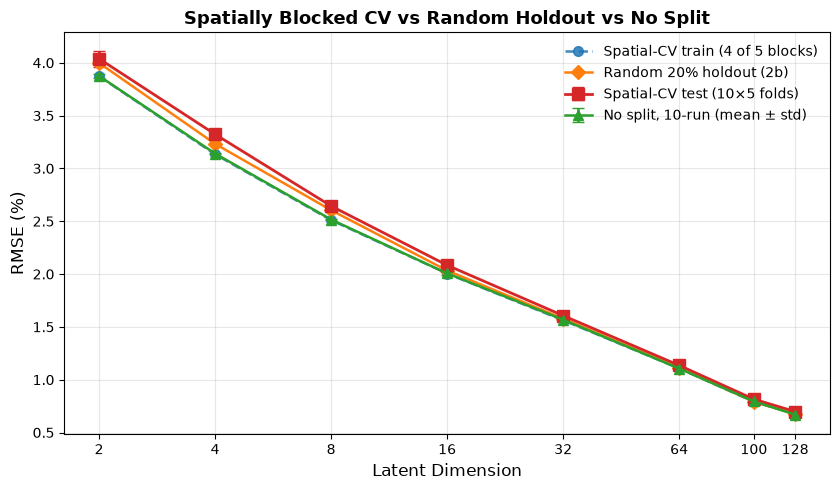

Saved plot: ../AE_outputs/retraining_stability_500epochs_linscaling_lad_blocked/spcv_vs_baselines.png


In [9]:
# --- Plot: spatial-CV test, spatial-CV train, random holdout, no-split ---

dims_sorted     = sorted(bottleneck_sizes)
spcv_test_mean  = np.array([spcv_summary[d]['test_mean']  for d in dims_sorted]) * 100
spcv_test_std   = np.array([spcv_summary[d]['test_std']   for d in dims_sorted]) * 100
spcv_train_mean = np.array([spcv_summary[d]['train_mean'] for d in dims_sorted]) * 100
nh_mean         = np.array([noholdout[d]['rmse_mean']     for d in dims_sorted]) * 100
nh_std          = np.array([noholdout[d]['rmse_std']      for d in dims_sorted]) * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.errorbar(dims_sorted, spcv_test_mean, yerr=spcv_test_std, fmt='s-', color='tab:red',
            label=f'Spatial-CV test ({n_repeats}×{n_folds} folds)', markersize=8, linewidth=2, capsize=4)
ax.plot(dims_sorted, spcv_train_mean, 'o--', color='tab:blue',
        label='Spatial-CV train (4 of 5 blocks)', markersize=7, linewidth=1.8, alpha=0.85)
if random_holdout is not None:
    rh_vals = np.array([random_holdout[d]['rmse_mean'] for d in dims_sorted]) * 100
    ax.plot(dims_sorted, rh_vals, 'D-', color='tab:orange',
            label='Random 20% holdout', markersize=7, linewidth=1.8)
ax.errorbar(dims_sorted, nh_mean, yerr=nh_std, fmt='^-', color='tab:green',
            label='No split, 10-run (mean ± std)', markersize=7, linewidth=1.8, capsize=4)

ax.set_xscale('log', base=2)
ax.set_xticks(dims_sorted); ax.set_xticklabels(dims_sorted)
ax.set_xlabel('Latent Dimension', fontsize=12)
ax.set_ylabel('RMSE (%)', fontsize=12)
ax.set_title('Spatially Blocked CV vs Random Holdout vs No Split', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plot_path = f"{output_dir}/spcv_vs_baselines.png"
plt.savefig(plot_path, dpi=300, bbox_inches='tight')
plt.show()
print(f"Saved plot: {plot_path}")

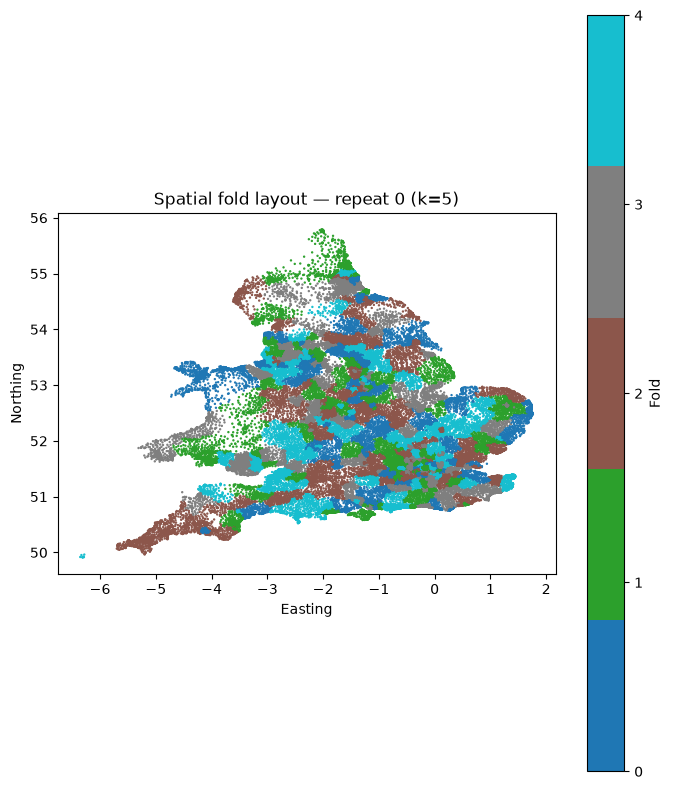

In [10]:
# --- Visualize one repeat's spatial fold layout ---

try:
    import matplotlib.colors as mcolors
    show_repeat = 0
    labels = fold_assignments[show_repeat]
    fig, ax = plt.subplots(figsize=(7, 8))
    cmap = plt.get_cmap('tab10', n_folds)
    sc = ax.scatter(XY[:, 0], XY[:, 1], c=labels, s=0.5, cmap=cmap)
    ax.set_aspect('equal')
    ax.set_title(f'Spatial fold layout — repeat {show_repeat} (k={n_folds})')
    ax.set_xlabel('Easting'); ax.set_ylabel('Northing')
    cbar = plt.colorbar(sc, ax=ax, ticks=range(n_folds))
    cbar.set_label('Fold')
    plt.tight_layout()
    plt.savefig(f"{output_dir}/spatial_folds_repeat{show_repeat}.png", dpi=200, bbox_inches='tight')
    plt.show()
except Exception as e:
    print(f"Skipped fold map: {e}")

## PCA Baseline on Same Spatial Folds

Fit PCA inside each spatial fold (train on 4 blocks, evaluate on the held-out block).
Aggregate RMSE the same way as the AE results.


PCA 128D ...


  repeat 0: done


  repeat 1: done


  repeat 2: done


  repeat 3: done


...

  repeat 5: done


  repeat 6: done


  repeat 7: done


  repeat 8: done


  repeat 9: done
   128D  PCA spatial test = 0.7459% ± 0.0268%   train = 0.7239%
   100D  PCA spatial test = 0.9652% ± 0.0294%   train = 0.9437%
    64D  PCA spatial test = 1.3812% ± 0.0362%   train = 1.3589%
    32D  PCA spatial test = 2.0544% ± 0.0440%   train = 2.0333%
    16D  PCA spatial test = 2.8390% ± 0.0528%   train = 2.8125%
     8D  PCA spatial test = 3.7440% ± 0.0743%   train = 3.7199%
     4D  PCA spatial test = 4.5810% ± 0.0772%   train = 4.5645%
     2D  PCA spatial test = 5.4632% ± 0.1087%   train = 5.4449%


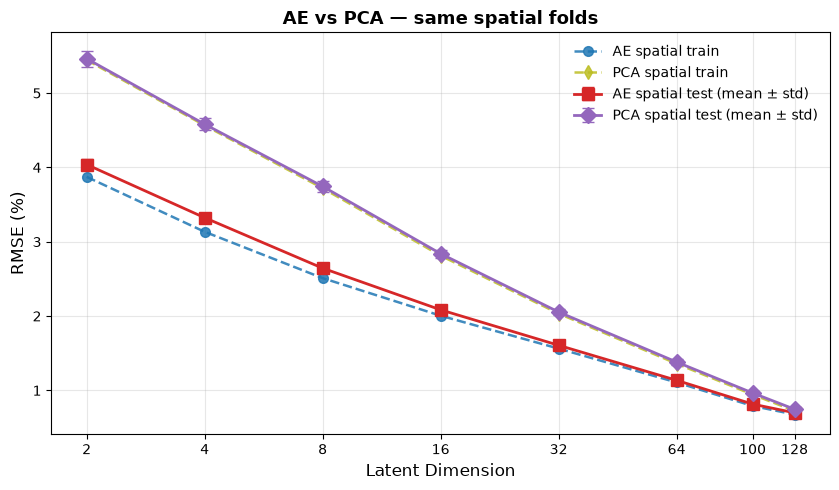


AE vs PCA on identical spatial folds
 Dimension  AE test mean (%)  AE test std (%)  PCA test mean (%)  PCA test std (%)  AE - PCA test (pp)
         2          4.038604         0.077095           5.463218          0.108712           -1.424613
         4          3.323187         0.054119           4.581010          0.077231           -1.257824
         8          2.644047         0.043024           3.744039          0.074279           -1.099991
        16          2.083624         0.033630           2.838955          0.052819           -0.755332
        32          1.606623         0.028444           2.054364          0.043951           -0.447740
        64          1.135392         0.024667           1.381207          0.036199           -0.245815
       100          0.815536         0.029831           0.965176          0.029399           -0.149640
       128          0.698125         0.037229           0.745851          0.026818           -0.047726


In [11]:
# --- PCA baseline on identical (repeat, fold) splits ---
from sklearn.decomposition import PCA

pca_results = {}  # (dim, repeat, fold) -> {'train_rmse','test_rmse'}

for latent_dim in bottleneck_sizes:
    print(f"\nPCA {latent_dim}D ...")
    for r in range(n_repeats):
        labels = fold_assignments[r]
        for f in range(n_folds):
            test_mask  = labels == f
            train_idx_ = np.where(~test_mask)[0]
            test_idx_  = np.where( test_mask)[0]
            X_tr = X_full[train_idx_]
            X_te = X_full[test_idx_]
            pca = PCA(n_components=latent_dim, svd_solver='randomized', random_state=base_split_seed + r)
            Z_tr = pca.fit_transform(X_tr)
            X_tr_reco = pca.inverse_transform(Z_tr)
            X_te_reco = pca.inverse_transform(pca.transform(X_te))
            pca_results[(latent_dim, r, f)] = {
                'train_rmse': float(np.sqrt(np.mean((X_tr - X_tr_reco) ** 2))),
                'test_rmse':  float(np.sqrt(np.mean((X_te - X_te_reco) ** 2))),
            }
        print(f"  repeat {r}: done")

# Aggregate per dim
pca_summary = {}
for d in bottleneck_sizes:
    test_rmses  = [pca_results[(d, r, f)]['test_rmse']  for r in range(n_repeats) for f in range(n_folds)]
    train_rmses = [pca_results[(d, r, f)]['train_rmse'] for r in range(n_repeats) for f in range(n_folds)]
    pca_summary[d] = {
        'test_mean':  float(np.mean(test_rmses)),
        'test_std':   float(np.std(test_rmses)),
        'train_mean': float(np.mean(train_rmses)),
        'train_std':  float(np.std(train_rmses)),
    }
    print(f"  {d:>4}D  PCA spatial test = {pca_summary[d]['test_mean']*100:.4f}% ± {pca_summary[d]['test_std']*100:.4f}%   "
          f"train = {pca_summary[d]['train_mean']*100:.4f}%")

with open(f"{output_dir}/data/pca_spcv_results.pkl", 'wb') as f:
    pickle.dump({'per_fold': pca_results, 'summary': pca_summary}, f)

# --- Combined plot: AE vs PCA on spatial folds ---
dims_sorted = sorted(bottleneck_sizes)
ae_test  = np.array([spcv_summary[d]['test_mean']  for d in dims_sorted]) * 100
ae_test_s= np.array([spcv_summary[d]['test_std']   for d in dims_sorted]) * 100
ae_train = np.array([spcv_summary[d]['train_mean'] for d in dims_sorted]) * 100
pc_test  = np.array([pca_summary[d]['test_mean']   for d in dims_sorted]) * 100
pc_test_s= np.array([pca_summary[d]['test_std']    for d in dims_sorted]) * 100
pc_train = np.array([pca_summary[d]['train_mean']  for d in dims_sorted]) * 100

fig, ax = plt.subplots(figsize=(8.5, 5))
ax.errorbar(dims_sorted, ae_test, yerr=ae_test_s, fmt='s-', color='tab:red',
            label='AE spatial test (mean ± std)', markersize=8, linewidth=2, capsize=4)
ax.plot(dims_sorted, ae_train, 'o--', color='tab:blue', label='AE spatial train', markersize=7, linewidth=1.8, alpha=0.85)
ax.errorbar(dims_sorted, pc_test, yerr=pc_test_s, fmt='D-', color='tab:purple',
            label='PCA spatial test (mean ± std)', markersize=8, linewidth=2, capsize=4)
ax.plot(dims_sorted, pc_train, 'd--', color='tab:olive', label='PCA spatial train', markersize=7, linewidth=1.8, alpha=0.85)
ax.set_xscale('log', base=2)
ax.set_xticks(dims_sorted); ax.set_xticklabels(dims_sorted)
ax.set_xlabel('Latent Dimension', fontsize=12)
ax.set_ylabel('RMSE (%)', fontsize=12)
ax.set_title('AE vs PCA — same spatial folds', fontsize=13, fontweight='bold')
ax.grid(True, alpha=0.3)
ax.legend(frameon=False, fontsize=10)
plt.tight_layout()
plt.savefig(f"{output_dir}/ae_vs_pca_spcv.png", dpi=300, bbox_inches='tight')
plt.show()

pca_df = pd.DataFrame([
    {'Dimension': d,
     'AE test mean (%)':  spcv_summary[d]['test_mean']*100,
     'AE test std (%)':   spcv_summary[d]['test_std']*100,
     'PCA test mean (%)': pca_summary[d]['test_mean']*100,
     'PCA test std (%)':  pca_summary[d]['test_std']*100,
     'AE - PCA test (pp)':(spcv_summary[d]['test_mean']-pca_summary[d]['test_mean'])*100}
    for d in dims_sorted
])
print("\n" + "="*100)
print("AE vs PCA on identical spatial folds")
print("="*100)
print(pca_df.to_string(index=False))
pca_df.to_csv(f"{output_dir}/data/ae_vs_pca_spcv.csv", index=False)